In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.ticker as mticker
from matplotlib.gridspec import GridSpec

In [2]:
data = pd.read_csv("order_dataset.csv")

In [3]:
data.head()

,Item Name,Category,Version,Item Code,Item ID,Buyer ID,Transaction ID,Date,Final Quantity,Total Revenue,Price Reductions,Refunds,Final Revenue,Sales Tax,Overall Revenue,Refunded Item Count,Purchased Item Count
0,QID,Product H,32 / B / 30,27-0CD-F44-7E1-0-2F608D7,46567054.0,3301861.0,5.363560e+13,14/04/2019,1,74.17,0.0,0.00,74.17,14.83,89.0,0,1
1,OTH,Product P,32 / B / FtO,37-9D1-AC6-D48-E-F2D4507,16345004.0,1205940.0,4.759180e+13,14/02/2019,-1,0.00,0.0,-79.17,-79.17,-15.83,-95.0,-1,0
2,WHX,Product P,32 / B / FtO,85-2EB-163-D62-5-FC50316,26246865.0,3342830.0,9.211720e+13,28/11/2018,-1,0.00,0.0,-74.17,-74.17,-14.83,-89.0,-1,0
3,RJF,Product P,33 / B / FtO,3D-687-99C-14F-4-661E2E7,42015157.0,7251983.0,5.987730e+13,3/3/2019,1,79.17,0.0,0.00,79.17,15.83,95.0,0,1
4,TSH,Product D,34 / B / FtO,F9-9FA-787-104-B-DCEE379,40522014.0,9940388.0,3.658240e+13,26/11/2018,1,74.17,0.0,0.00,74.17,14.83,89.0,0,1


In [4]:
data.describe().round(2)

,Item ID,Buyer ID,Transaction ID,Final Quantity,Total Revenue,Price Reductions,Refunds,Final Revenue,Sales Tax,Overall Revenue,Refunded Item Count,Purchased Item Count
count,7.005200e+04,7.005200e+04,7.005200e+04,70052.00,70052.00,70052.00,70052.00,70052.00,70052.00,70052.00,70052.00,70052.00
mean,2.442318e+11,6.013091e+11,5.506075e+13,0.70,61.78,-4.95,-10.25,46.58,9.12,55.70,-0.16,0.86
std,4.255077e+12,6.223201e+12,2.587640e+13,0.74,31.80,7.77,25.15,51.80,10.31,61.92,0.37,0.38
min,1.001447e+07,1.000661e+06,1.000660e+13,-3.00,0.00,-200.00,-237.50,-237.50,-47.50,-285.00,-3.00,0.00
25%,2.692223e+07,3.295695e+06,3.270320e+13,1.00,51.67,-8.34,0.00,47.08,8.38,56.23,0.00,1.00
50%,4.494514e+07,5.566107e+06,5.522210e+13,1.00,74.17,0.00,0.00,63.33,12.66,76.00,0.00,1.00
75%,7.743106e+07,7.815352e+06,7.736880e+13,1.00,79.17,0.00,0.00,74.17,14.84,89.00,0.00,1.00
max,8.422210e+13,9.977410e+13,9.999550e+13,6.00,445.00,0.00,0.00,445.00,63.34,445.00,0.00,6.00


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70052 entries, 0 to 70051
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Item Name             70052 non-null  object 
 1   Category              70052 non-null  object 
 2   Version               70052 non-null  object 
 3   Item Code             70052 non-null  object 
 4   Item ID               70052 non-null  float64
 5   Buyer ID              70052 non-null  float64
 6   Transaction ID        70052 non-null  float64
 7   Date                  70052 non-null  object 
 8   Final Quantity        70052 non-null  int64  
 9   Total Revenue         70052 non-null  float64
 10  Price Reductions      70052 non-null  float64
 11  Refunds               70052 non-null  float64
 12  Final Revenue         70052 non-null  float64
 13  Sales Tax             70052 non-null  float64
 14  Overall Revenue       70052 non-null  float64
 15  Refunded Item Count

In [6]:
data.isnull().sum()

Item Name               0
Category                0
Version                 0
Item Code               0
Item ID                 0
Buyer ID                0
Transaction ID          0
Date                    0
Final Quantity          0
Total Revenue           0
Price Reductions        0
Refunds                 0
Final Revenue           0
Sales Tax               0
Overall Revenue         0
Refunded Item Count     0
Purchased Item Count    0
dtype: int64

In [7]:
data.shape

(70052, 17)

In [8]:
data['Date'] = pd.to_datetime(data['Date'], dayfirst=True, errors='coerce')
# find date range
print(data['Date'].min().date())
print(data['Date'].max().date())

2018-11-01
2019-04-30


In [9]:
#unique products, categories and Buyer IDs
print(data['Item Name'].nunique())
print(data['Category'].nunique())
print(data['Buyer ID'].nunique())

49
23
25543


In [10]:
# separating sales and returns
sales = data[data['Final Quantity'] > 0].copy()
returns = data[data['Final Quantity'] < 0].copy()

In [11]:
sales.head()

,Item Name,Category,Version,Item Code,Item ID,Buyer ID,Transaction ID,Date,Final Quantity,Total Revenue,Price Reductions,Refunds,Final Revenue,Sales Tax,Overall Revenue,Refunded Item Count,Purchased Item Count
0,QID,Product H,32 / B / 30,27-0CD-F44-7E1-0-2F608D7,46567054.0,3301861.0,5.363560e+13,2019-04-14,1,74.17,0.0,0.0,74.17,14.83,89.0,0,1
3,RJF,Product P,33 / B / FtO,3D-687-99C-14F-4-661E2E7,42015157.0,7251983.0,5.987730e+13,2019-03-03,1,79.17,0.0,0.0,79.17,15.83,95.0,0,1
4,TSH,Product D,34 / B / FtO,F9-9FA-787-104-B-DCEE379,40522014.0,9940388.0,3.658240e+13,2018-11-26,1,74.17,0.0,0.0,74.17,14.83,89.0,0,1
5,BKT,Product Q,37 / B / 28,92-F5E-879-C1C-4-447E57D,32047144.0,9139641.0,2.956120e+13,2019-01-02,1,36.67,0.0,0.0,36.67,7.33,44.0,0,1
6,TSH,Product P,34 / B / FtO,30-612-F8B-3F0-D-1399050,40522014.0,3621461.0,1.192810e+13,2018-12-26,1,55.00,0.0,0.0,55.00,11.00,66.0,0,1


In [12]:
returns.head()

,Item Name,Category,Version,Item Code,Item ID,Buyer ID,Transaction ID,Date,Final Quantity,Total Revenue,Price Reductions,Refunds,Final Revenue,Sales Tax,Overall Revenue,Refunded Item Count,Purchased Item Count
1,OTH,Product P,32 / B / FtO,37-9D1-AC6-D48-E-F2D4507,16345004.0,1205940.0,4.759180e+13,2019-02-14,-1,0.0,0.0,-79.17,-79.17,-15.83,-95.0,-1,0
2,WHX,Product P,32 / B / FtO,85-2EB-163-D62-5-FC50316,26246865.0,3342830.0,9.211720e+13,2018-11-28,-1,0.0,0.0,-74.17,-74.17,-14.83,-89.0,-1,0
8,WHX,Product A,34 / A / FtO,BB-624-2EC-849-6-55C3AE9,70509397.0,5467593.0,6.641700e+13,2019-03-20,-1,0.0,0.0,-107.50,-107.50,-21.50,-129.0,-1,0
17,RJF,Product P,35 / B / FtO,22-6A3-ACF-C57-6-3147EE4,88162726.0,5950642.0,1.344600e+13,2019-04-02,-1,0.0,0.0,-79.16,-79.16,-15.84,-95.0,-1,0
22,WHX,Product D,32 / A / 29,5A-02C-11D-258-0-EDB1CFD,29157946.0,4471680.0,4.726770e+13,2019-02-06,-1,0.0,0.0,-74.17,-74.17,-14.83,-89.0,-1,0


In [13]:
for frame in [data, sales, returns]:
    frame['YearMonth']  = frame['Date'].dt.to_period('M').astype(str)
    frame['DayOfWeek']  = frame['Date'].dt.day_name()
    frame['Month']      = frame['Date'].dt.month
    frame['Week']       = frame['Date'].dt.isocalendar().week.astype(int)


In [14]:
data.head()

,Item Name,Category,Version,Item Code,Item ID,Buyer ID,Transaction ID,Date,Final Quantity,Total Revenue,...,Refunds,Final Revenue,Sales Tax,Overall Revenue,Refunded Item Count,Purchased Item Count,YearMonth,DayOfWeek,Month,Week
0,QID,Product H,32 / B / 30,27-0CD-F44-7E1-0-2F608D7,46567054.0,3301861.0,5.363560e+13,2019-04-14,1,74.17,...,0.00,74.17,14.83,89.0,0,1,2019-04,Sunday,4,15
1,OTH,Product P,32 / B / FtO,37-9D1-AC6-D48-E-F2D4507,16345004.0,1205940.0,4.759180e+13,2019-02-14,-1,0.00,...,-79.17,-79.17,-15.83,-95.0,-1,0,2019-02,Thursday,2,7
2,WHX,Product P,32 / B / FtO,85-2EB-163-D62-5-FC50316,26246865.0,3342830.0,9.211720e+13,2018-11-28,-1,0.00,...,-74.17,-74.17,-14.83,-89.0,-1,0,2018-11,Wednesday,11,48
3,RJF,Product P,33 / B / FtO,3D-687-99C-14F-4-661E2E7,42015157.0,7251983.0,5.987730e+13,2019-03-03,1,79.17,...,0.00,79.17,15.83,95.0,0,1,2019-03,Sunday,3,9
4,TSH,Product D,34 / B / FtO,F9-9FA-787-104-B-DCEE379,40522014.0,9940388.0,3.658240e+13,2018-11-26,1,74.17,...,0.00,74.17,14.83,89.0,0,1,2018-11,Monday,11,48


In [15]:
len(sales)

59269

In [16]:
len(returns)

10715

In [17]:
round(len(returns)/len(sales)*100,2)

18.08

In [18]:
# Financial summary
gross  = sales['Overall Revenue'].sum()
total_refunds = returns['Refunds'].sum()
net    = gross + total_refunds

print(gross)
print(total_refunds)
print(net)

4757035.3
-713669.02
4043366.28


In [19]:
## Sales trends and Seasonality

monthly_sales = sales.groupby('YearMonth')['Overall Revenue'].sum()
monthly_returns = returns.groupby('YearMonth')['Refunds'].sum().abs()
monthly_net = monthly_sales - monthly_returns
monthly_vol_sales = sales.groupby('YearMonth')['Purchased Item Count'].sum()
monthly_vol_returns = returns.groupby('YearMonth')['Refunded Item Count'].sum().abs()
monthly_vol_net = monthly_vol_sales - monthly_vol_returns

In [20]:
accent   = '#c84b2f'
blue     = '#2f6fc8'
green    = '#2a9d5c'
gold     = '#c8961f'
purple   = '#7b5ea7'

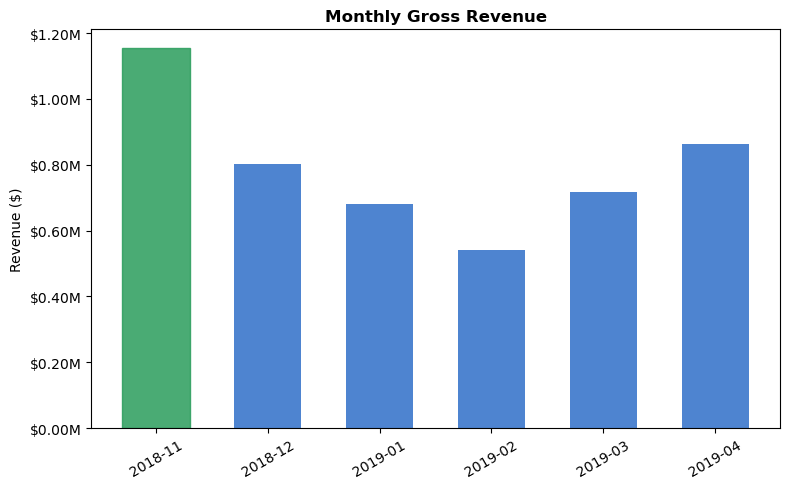

In [21]:
plt.figure(figsize=(8, 5))

bars = plt.bar(
    monthly_sales.index,
    monthly_sales.values,
    color=blue,
    alpha=0.85,
    width=0.6
)

bars[0].set_color(green)  # highlight peak

plt.title('Monthly Gross Revenue', fontweight='bold')
plt.ylabel('Revenue ($)')

plt.gca().yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'${x/1e6:.2f}M')
)

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

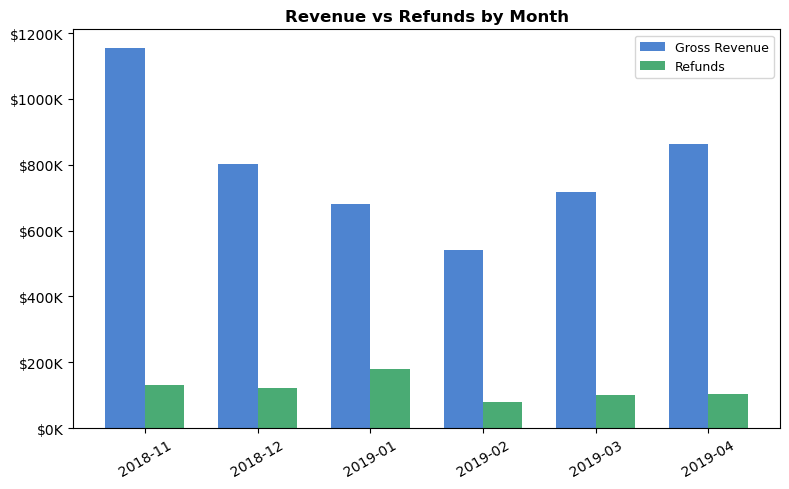

In [22]:
plt.figure(figsize=(8, 5))

x = np.arange(len(monthly_sales))
w = 0.35

plt.bar(x - w/2, monthly_sales.values, w,
        label='Gross Revenue', color=blue, alpha=0.85)

plt.bar(x + w/2, monthly_returns.values, w,
        label='Refunds', color=green, alpha=0.85)

plt.xticks(x, monthly_sales.index, rotation=30)

plt.title('Revenue vs Refunds by Month', fontweight='bold')

plt.gca().yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K')
)

plt.legend(fontsize=9)

plt.tight_layout()
plt.show()

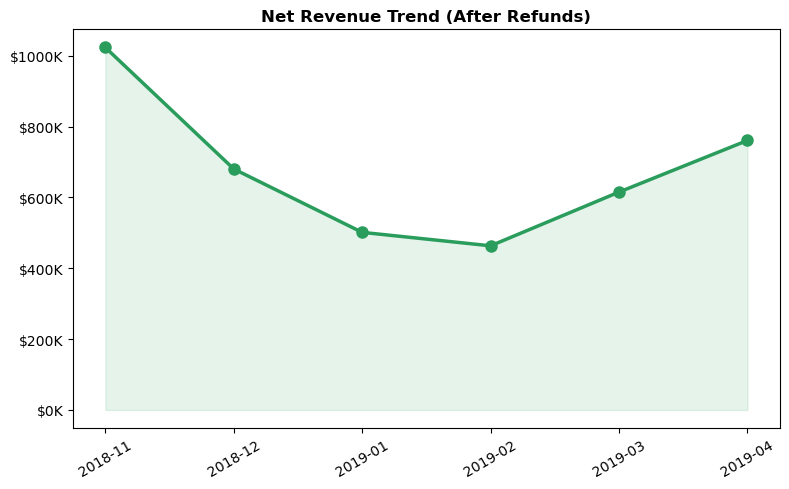

In [23]:
plt.figure(figsize=(8, 5))

x = np.arange(len(monthly_net))

plt.plot(x, monthly_net.values,
         marker='o',
         color=green,
         linewidth=2.5,
         markersize=8)

plt.fill_between(x, monthly_net.values,
                 alpha=0.12,
                 color=green)

plt.xticks(x, monthly_net.index, rotation=30)

plt.title('Net Revenue Trend (After Refunds)', fontweight='bold')

plt.gca().yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K')
)

plt.tight_layout()
plt.show()

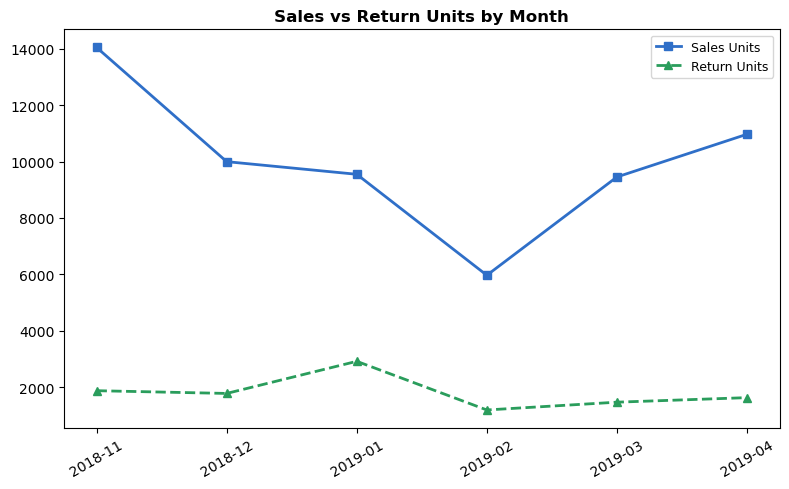

In [24]:
plt.figure(figsize=(8, 5))

x = np.arange(len(monthly_vol_sales))

plt.plot(x, monthly_vol_sales.values,
         marker='s',
         color=blue,
         linewidth=2,
         label='Sales Units')

plt.plot(x, monthly_vol_returns.values,
         marker='^',
         color=green,
         linewidth=2,
         linestyle='--',
         label='Return Units')

plt.xticks(x, monthly_vol_sales.index, rotation=30)

plt.title('Sales vs Return Units by Month', fontweight='bold')

plt.legend(fontsize=9)

plt.tight_layout()
plt.show()

In [25]:
# day of week analysis

dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dow_rev   = sales.groupby('DayOfWeek')['Overall Revenue'].sum().reindex(dow_order)
dow_cnt   = sales.groupby('DayOfWeek')['Purchased Item Count'].sum().reindex(dow_order)

# Month-over-Month change
mom = monthly_sales.pct_change() * 100


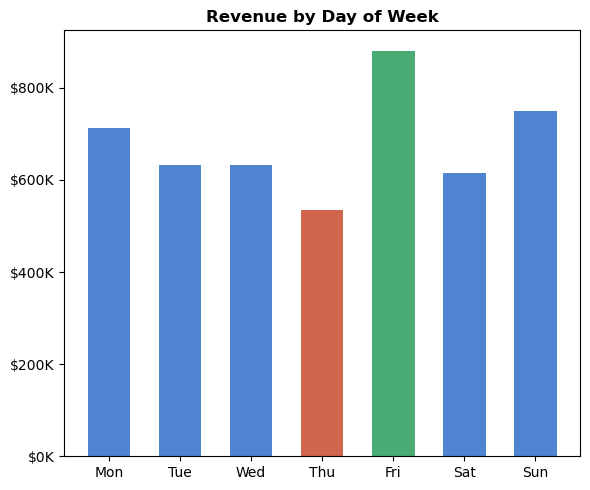

In [26]:
plt.figure(figsize=(6, 5))

colors_dow = [
    green if v == dow_rev.max()
    else (accent if v == dow_rev.min() else blue)
    for v in dow_rev
]

plt.bar(dow_order, dow_rev.values,
        color=colors_dow,
        alpha=0.85,
        width=0.6)

plt.title('Revenue by Day of Week', fontweight='bold')
plt.xticks(ticks=range(len(dow_order)),
           labels=[d[:3] for d in dow_order])

plt.gca().yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K')
)

plt.tight_layout()
plt.show()

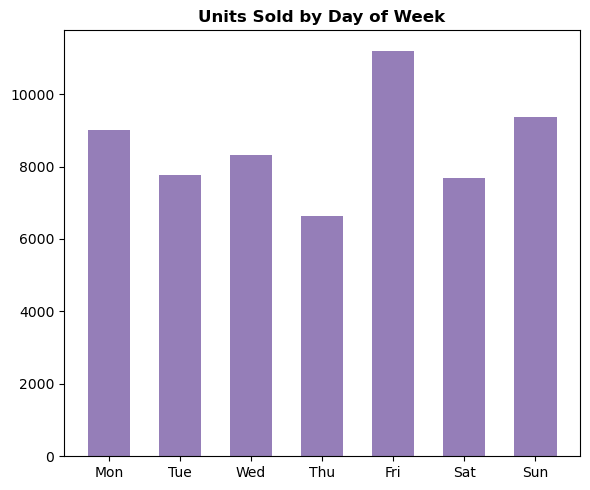

In [27]:
plt.figure(figsize=(6, 5))

plt.bar(dow_order, dow_cnt.values,
        color=purple,
        alpha=0.8,
        width=0.6)

plt.title('Units Sold by Day of Week', fontweight='bold')

plt.xticks(ticks=range(len(dow_order)),
           labels=[d[:3] for d in dow_order])

plt.tight_layout()
plt.show()

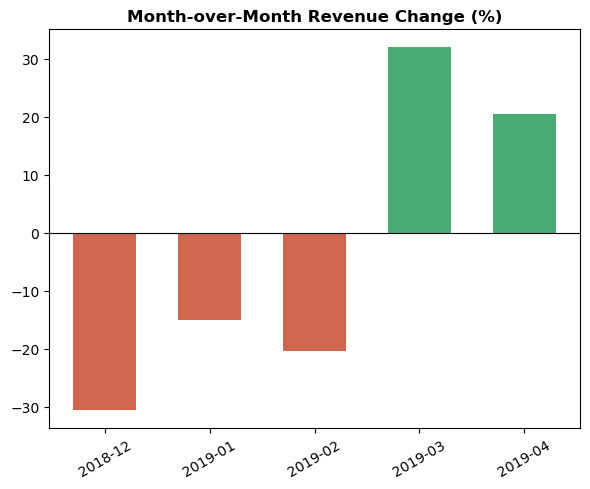

In [28]:
plt.figure(figsize=(6, 5))

mom_vals = mom.dropna()
mom_colors = [green if v >= 0 else accent for v in mom_vals]

plt.bar(mom_vals.index,
        mom_vals.values,
        color=mom_colors,
        alpha=0.85,
        width=0.6)

plt.axhline(0, color='black', linewidth=0.8)

plt.title('Month-over-Month Revenue Change (%)', fontweight='bold')
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

In [29]:
print(f'\n Peak day     : {dow_rev.idxmax()} (${dow_rev.max():,.0f})')
print(f' Slowest day  : {dow_rev.idxmin()} (${dow_rev.min():,.0f})')


 Peak day     : Friday ($880,982)
 Slowest day  : Thursday ($535,825)


In [30]:
# Category-level analysis
cat_rev   = sales.groupby('Category')['Overall Revenue'].sum().sort_values(ascending=False)
cat_units = sales.groupby('Category')['Purchased Item Count'].sum().sort_values(ascending=False)


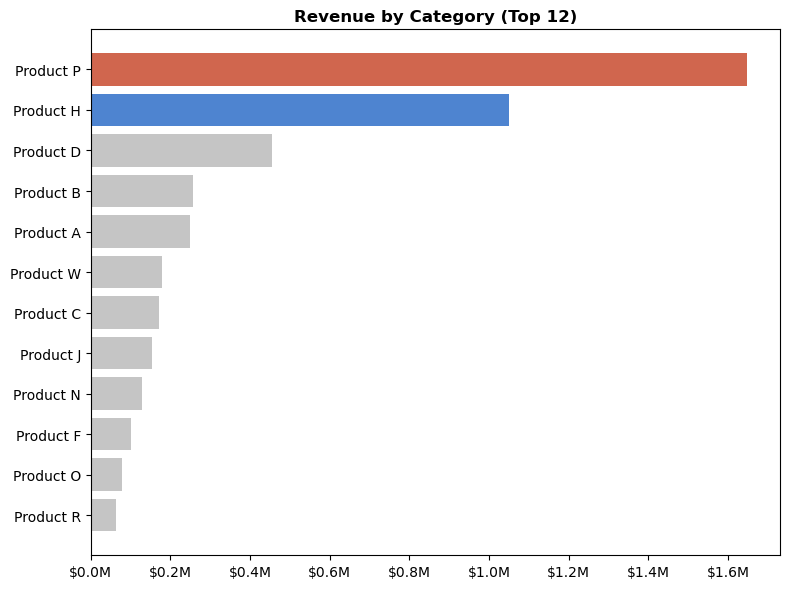

In [31]:
plt.figure(figsize=(8, 6))

top_cat = cat_rev.head(12)

colors = [
    accent if i == 0 else (blue if i == 1 else '#bbb')
    for i in range(len(top_cat))
]

plt.barh(
    top_cat.index[::-1],
    top_cat.values[::-1],
    color=colors[::-1],
    alpha=0.85
)

plt.title('Revenue by Category (Top 12)', fontweight='bold')

plt.gca().xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M')
)

plt.tight_layout()
plt.show()

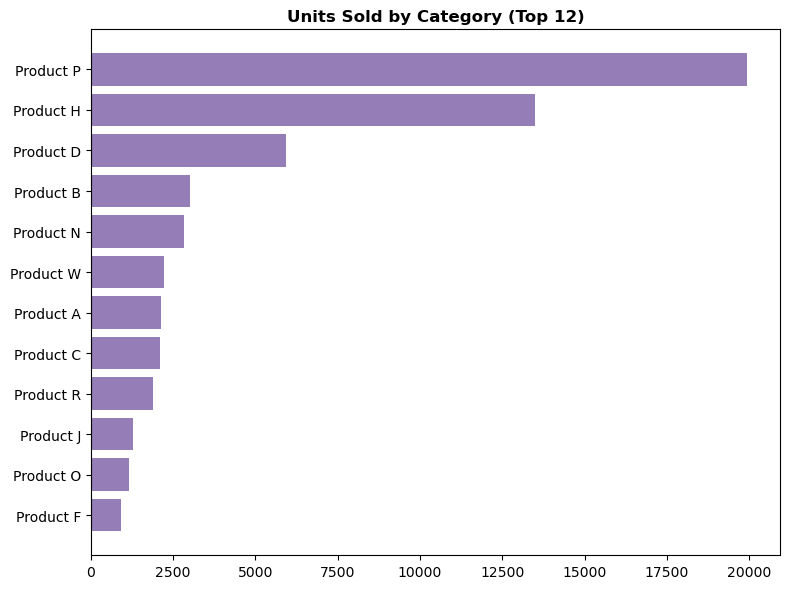

In [32]:
plt.figure(figsize=(8, 6))

top_units = cat_units.head(12)

plt.barh(
    top_units.index[::-1],
    top_units.values[::-1],
    color=purple,
    alpha=0.8
)

plt.title('Units Sold by Category (Top 12)', fontweight='bold')

plt.tight_layout()
plt.show()

In [33]:
total = cat_rev.sum()

print('\n--- REVENUE SHARE BY CATEGORY ---')
for cat, rev in cat_rev.head(5).items():
    print(f'  {cat:<14}: ${rev:>10,.0f}  ({rev/total*100:.1f}%)')


--- REVENUE SHARE BY CATEGORY ---
  Product P     : $ 1,648,334  (34.7%)
  Product H     : $ 1,049,603  (22.1%)
  Product D     : $   455,988  (9.6%)
  Product B     : $   257,341  (5.4%)
  Product A     : $   248,816  (5.2%)


In [34]:
item_rev   = sales.groupby('Item Name')['Overall Revenue'].sum().sort_values(ascending=False)
item_units = sales.groupby('Item Name')['Purchased Item Count'].sum().sort_values(ascending=False)

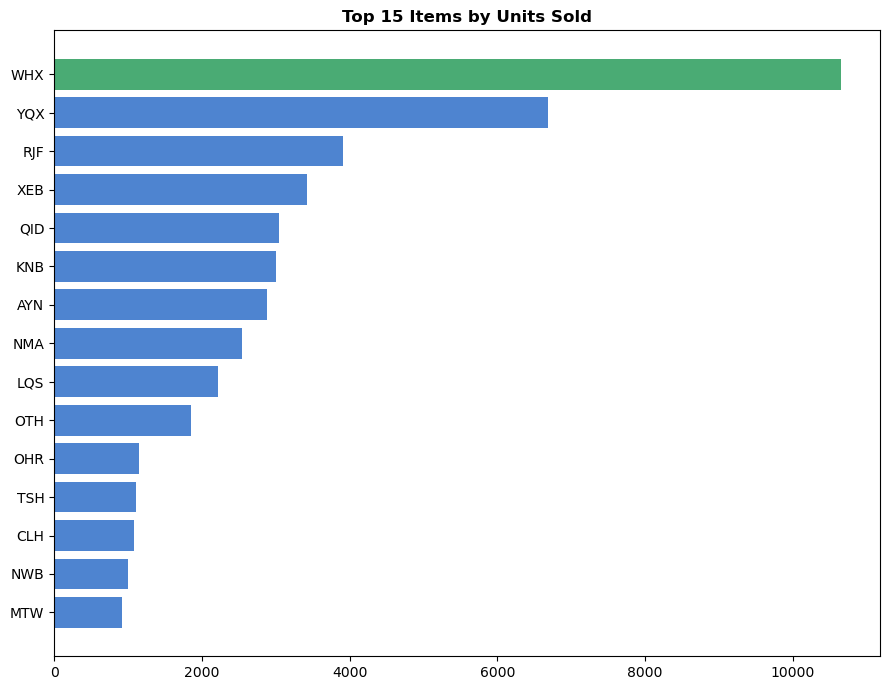

In [35]:
plt.figure(figsize=(9, 7))

top15_items = item_units.head(15)

bar_colors = [
    green if i == 0 else blue
    for i in range(len(top15_items))
]

plt.barh(
    top15_items.index[::-1],
    top15_items.values[::-1],
    color=bar_colors[::-1],
    alpha=0.85
)

plt.title('Top 15 Items by Units Sold', fontweight='bold')

plt.tight_layout()
plt.show()

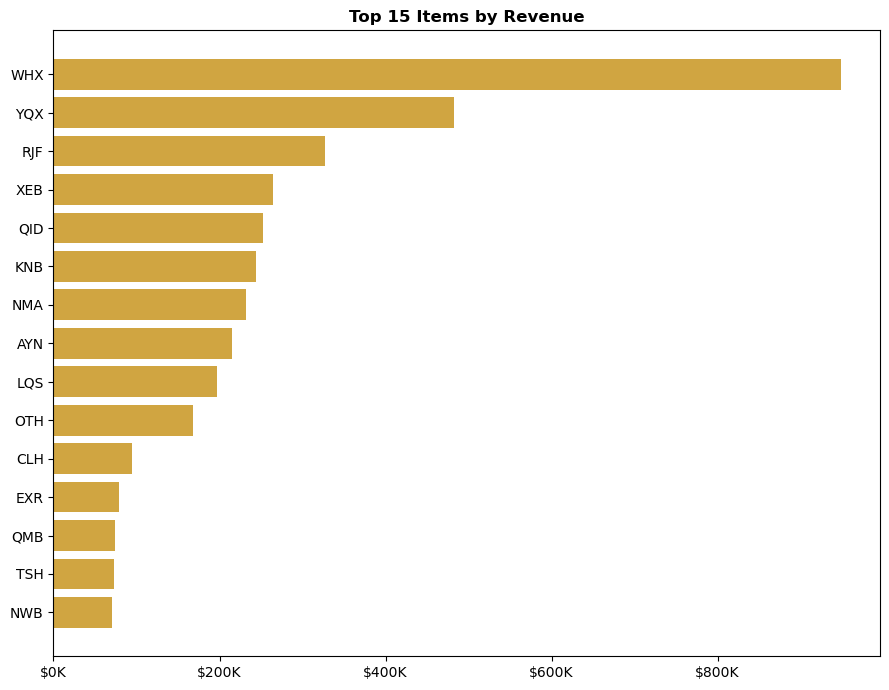

In [36]:
plt.figure(figsize=(9, 7))

top15_rev = item_rev.head(15)

plt.barh(
    top15_rev.index[::-1],
    top15_rev.values[::-1],
    color=gold,
    alpha=0.85
)

plt.title('Top 15 Items by Revenue', fontweight='bold')

plt.gca().xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K')
)

plt.tight_layout()
plt.show()

In [37]:
version_units = sales.groupby('Version')['Purchased Item Count'].sum().sort_values(ascending=False).head(15)

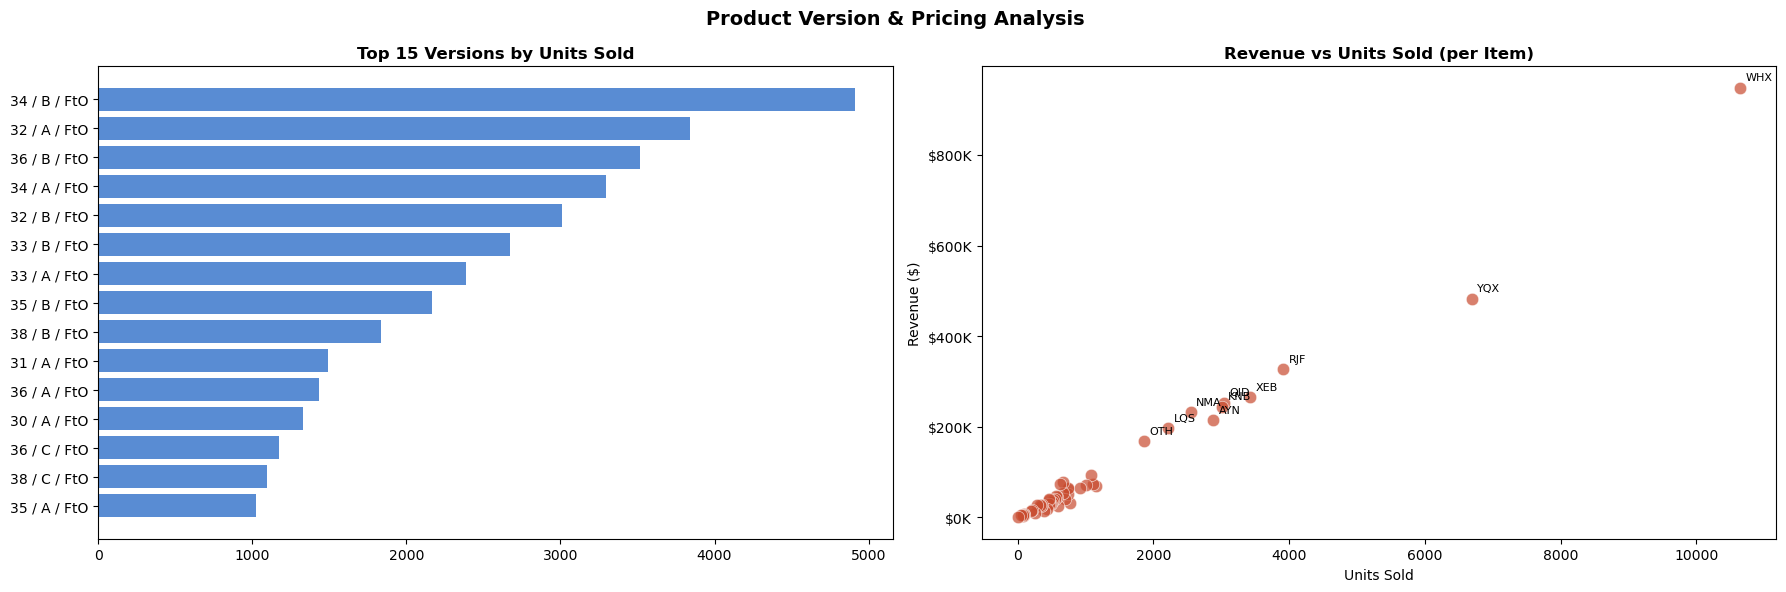

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Product Version & Pricing Analysis', fontsize=14, fontweight='bold')

axes[0].barh(version_units.index[::-1], version_units.values[::-1], color=blue, alpha=0.8)
axes[0].set_title('Top 15 Versions by Units Sold', fontweight='bold')

# Revenue vs units scatter
common = item_units.index.intersection(item_rev.index)
x_vals = item_units[common].values
y_vals = item_rev[common].values
axes[1].scatter(x_vals, y_vals, color=accent, alpha=0.7, s=80, edgecolors='white', linewidth=0.5)
for name, xu, yr in zip(common[:10], x_vals[:10], y_vals[:10]):
    axes[1].annotate(name, (xu, yr), fontsize=8, ha='left', va='bottom',
                     xytext=(4, 4), textcoords='offset points')
axes[1].set_xlabel('Units Sold')
axes[1].set_ylabel('Revenue ($)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))
axes[1].set_title('Revenue vs Units Sold (per Item)', fontweight='bold')

plt.tight_layout()
plt.show()

In [39]:
# Category return rates
cat_sales_cnt  = sales.groupby('Category')['Purchased Item Count'].sum()
cat_ret_cnt    = returns.groupby('Category')['Refunded Item Count'].sum().abs()
cat_return_rate = (cat_ret_cnt / cat_sales_cnt * 100).dropna().sort_values(ascending=False)

cat_refunds_amt = returns.groupby('Category')['Refunds'].sum().abs().sort_values(ascending=False)

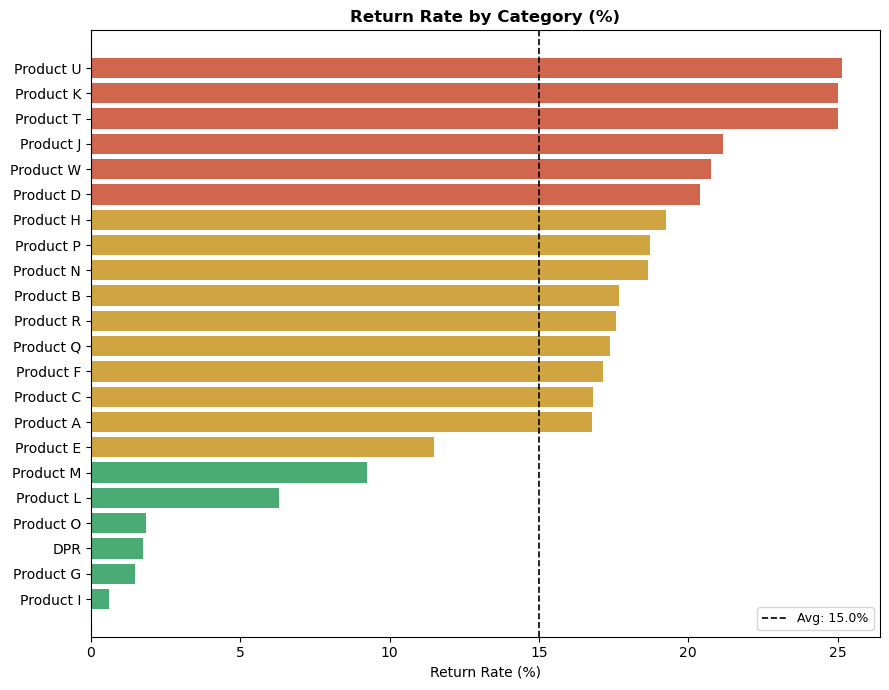

In [40]:
plt.figure(figsize=(9, 7))

rate_colors = [
    accent if v > 20 else (gold if v > 10 else green)
    for v in cat_return_rate.values
]

plt.barh(
    cat_return_rate.index[::-1],
    cat_return_rate.values[::-1],
    color=rate_colors[::-1],
    alpha=0.85
)

avg_rate = cat_return_rate.mean()

plt.axvline(
    avg_rate,
    color='black',
    linestyle='--',
    linewidth=1.2,
    label=f'Avg: {avg_rate:.1f}%'
)

plt.title('Return Rate by Category (%)', fontweight='bold')
plt.xlabel('Return Rate (%)')
plt.legend(fontsize=9)

plt.tight_layout()
plt.show()

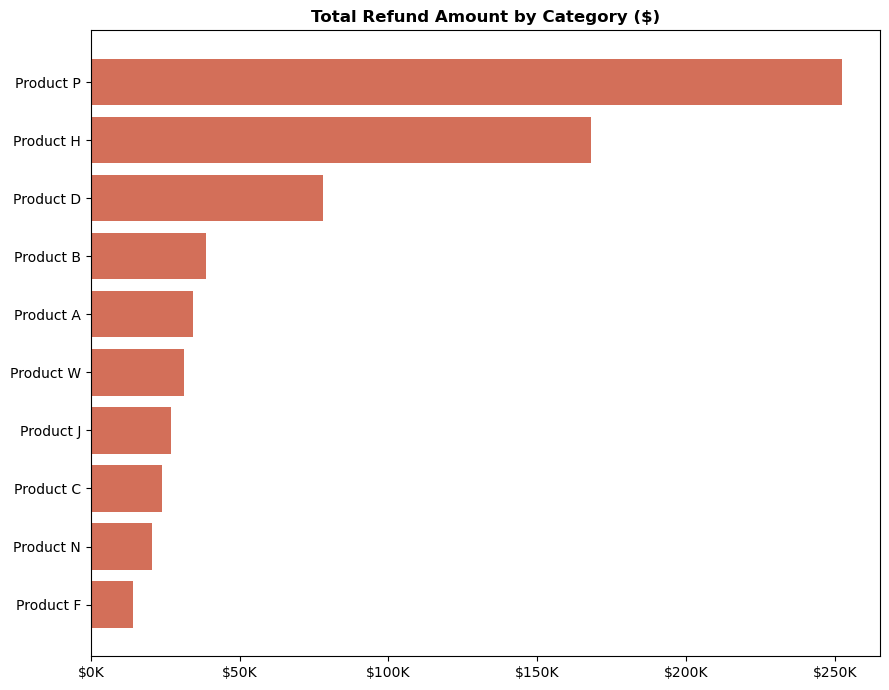

In [41]:
plt.figure(figsize=(9, 7))

top_refund = cat_refunds_amt.head(10)

plt.barh(
    top_refund.index[::-1],
    top_refund.values[::-1],
    color=accent,
    alpha=0.8
)

plt.title('Total Refund Amount by Category ($)', fontweight='bold')

plt.gca().xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K')
)

plt.tight_layout()
plt.show()

In [42]:
print(f'\nAvg category return rate : {cat_return_rate.mean():.1f}%')
print(f'Highest return rate      : {cat_return_rate.idxmax()} ({cat_return_rate.max():.1f}%)')
print(f'Lowest return rate       : {cat_return_rate.idxmin()} ({cat_return_rate.min():.1f}%)')


Avg category return rate : 15.0%
Highest return rate      : Product U (25.2%)
Lowest return rate       : Product I (0.6%)


In [43]:
item_sales_cnt = sales.groupby('Item Name')['Purchased Item Count'].sum()
item_ret_cnt   = returns.groupby('Item Name')['Refunded Item Count'].sum().abs()
item_ret_rate  = (item_ret_cnt / item_sales_cnt * 100).dropna().sort_values(ascending=False)

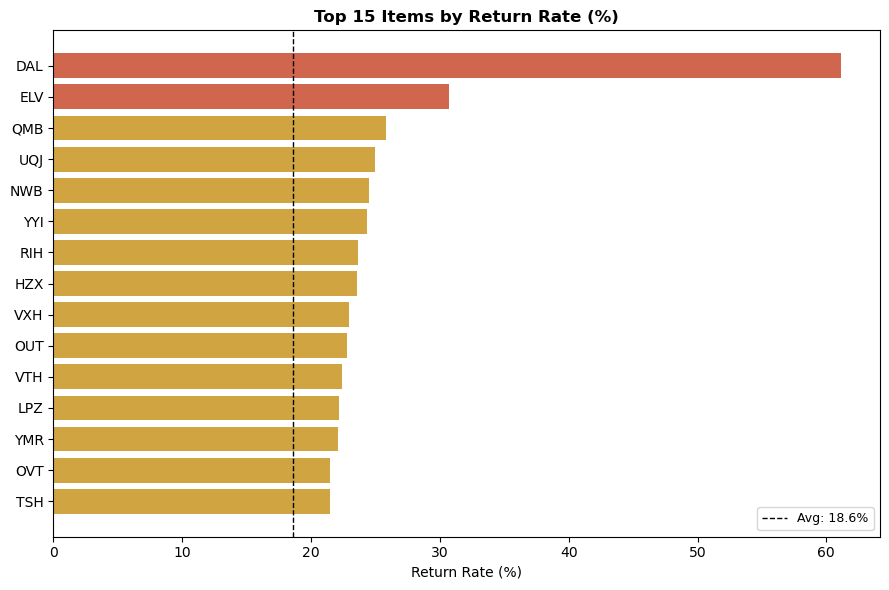

In [44]:
plt.figure(figsize=(9, 6))

top_ret = item_ret_rate.head(15)

ret_colors = [
    accent if v > 30 else (gold if v > 20 else blue)
    for v in top_ret.values
]

plt.barh(
    top_ret.index[::-1],
    top_ret.values[::-1],
    color=ret_colors[::-1],
    alpha=0.85
)

avg_ret = item_ret_rate.mean()

plt.axvline(
    avg_ret,
    color='black',
    linestyle='--',
    linewidth=1,
    label=f'Avg: {avg_ret:.1f}%'
)

plt.title('Top 15 Items by Return Rate (%)', fontweight='bold')
plt.xlabel('Return Rate (%)')
plt.legend(fontsize=9)

plt.tight_layout()
plt.show()

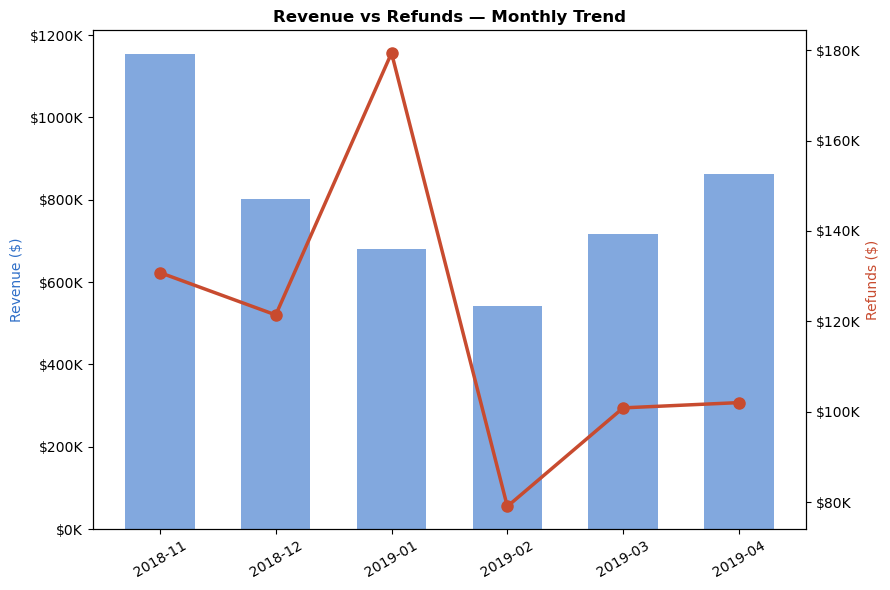

In [45]:
plt.figure(figsize=(9, 6))

m_ret = returns.groupby('YearMonth')['Refunds'].sum().abs()
m_sal = sales.groupby('YearMonth')['Overall Revenue'].sum()

# Primary axis (Revenue)
ax1 = plt.gca()

ax1.bar(
    m_sal.index,
    m_sal.values,
    color=blue,
    alpha=0.6,
    label='Gross Revenue',
    width=0.6
)

ax1.set_ylabel('Revenue ($)', color=blue)
ax1.tick_params(axis='x', rotation=30)

ax1.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K')
)

# Secondary axis (Refunds)
ax2 = ax1.twinx()

ax2.plot(
    m_ret.index,
    m_ret.values,
    marker='o',
    color=accent,
    linewidth=2.5,
    markersize=8,
    label='Refunds'
)

ax2.set_ylabel('Refunds ($)', color=accent)

ax2.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K')
)

plt.title('Revenue vs Refunds — Monthly Trend', fontweight='bold')

plt.tight_layout()
plt.show()

In [46]:
print('\n--- TOP 10 HIGH-RISK ITEMS (by return rate) ---')
print(item_ret_rate.head(10))


--- TOP 10 HIGH-RISK ITEMS (by return rate) ---
Item Name
DAL    61.111111
ELV    30.697674
QMB    25.837321
UQJ    24.954128
NWB    24.501992
YYI    24.332344
RIH    23.673469
HZX    23.529412
VXH    22.953020
OUT    22.795699
dtype: float64


In [47]:
# Correlation: sales volume vs return rate 
combined = pd.DataFrame({ 
    'Units Sold' : item_sales_cnt, 
    'Return Rate' : item_ret_rate, 
    'Revenue' : item_rev 
}).dropna()

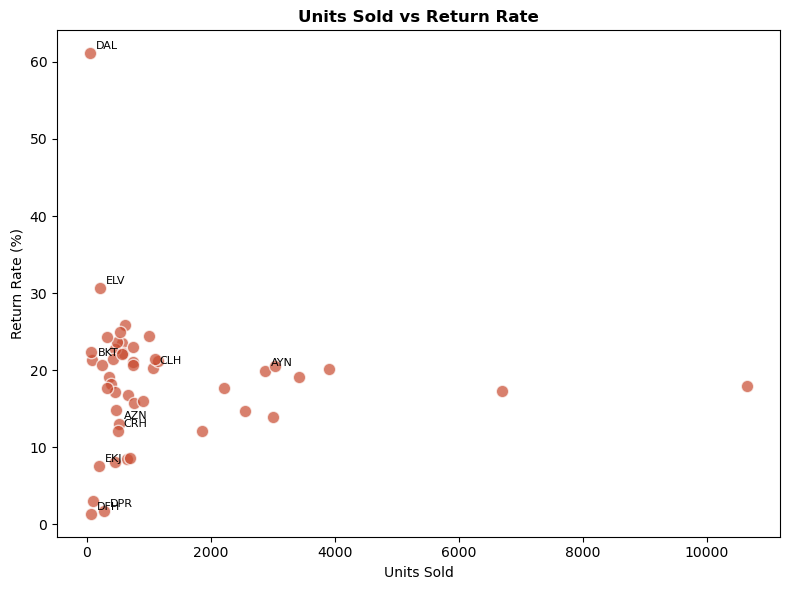

In [48]:
plt.figure(figsize=(8, 6))

plt.scatter(
    combined['Units Sold'],
    combined['Return Rate'],
    color=accent,
    alpha=0.7,
    s=80,
    edgecolors='white'
)

# Annotate first 10
for name, row in combined.head(10).iterrows():
    plt.annotate(
        name,
        (row['Units Sold'], row['Return Rate']),
        fontsize=8,
        xytext=(4, 3),
        textcoords='offset points'
    )

plt.xlabel('Units Sold')
plt.ylabel('Return Rate (%)')
plt.title('Units Sold vs Return Rate', fontweight='bold')

plt.tight_layout()
plt.show()

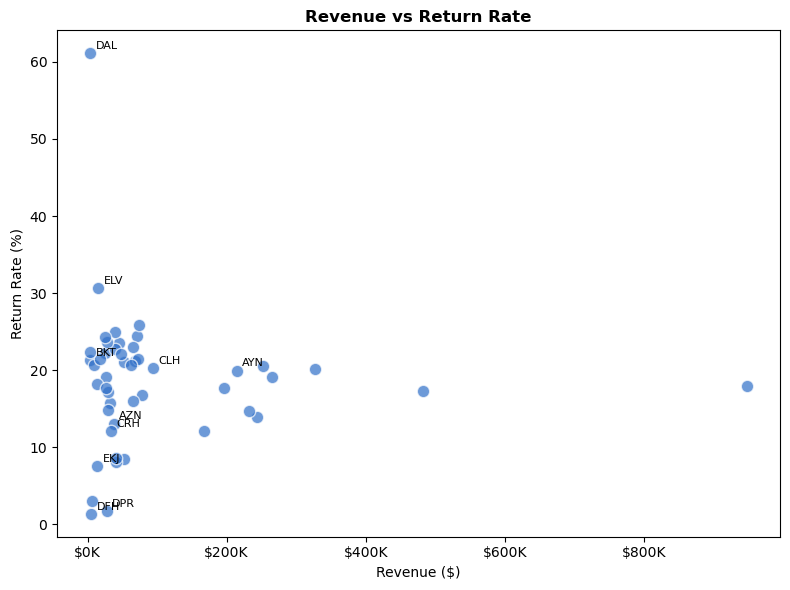

In [49]:
plt.figure(figsize=(8, 6))

plt.scatter(
    combined['Revenue'],
    combined['Return Rate'],
    color=blue,
    alpha=0.7,
    s=80,
    edgecolors='white'
)

# Annotate first 10
for name, row in combined.head(10).iterrows():
    plt.annotate(
        name,
        (row['Revenue'], row['Return Rate']),
        fontsize=8,
        xytext=(4, 3),
        textcoords='offset points'
    )

plt.xlabel('Revenue ($)')
plt.ylabel('Return Rate (%)')

plt.gca().xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K')
)

plt.title('Revenue vs Return Rate', fontweight='bold')

plt.tight_layout()
plt.show()

In [50]:
corr1 = combined['Units Sold'].corr(combined['Return Rate'])
corr2 = combined['Revenue'].corr(combined['Return Rate'])
print(f'\nCorrelation (Units Sold vs Return Rate) : {corr1:.3f}')
print(f'Correlation (Revenue vs Return Rate)    : {corr2:.3f}')


Correlation (Units Sold vs Return Rate) : -0.037
Correlation (Revenue vs Return Rate)    : -0.038


In [51]:
# Build RFM table
snapshot = data['Date'].max() + pd.Timedelta(days=1)

rfm = sales.groupby('Buyer ID').agg(
    Recency   = ('Date',            lambda x: (snapshot - x.max()).days),
    Frequency = ('Transaction ID',  'count'),
    Monetary  = ('Overall Revenue', 'sum')
).reset_index()

# Score each dimension 1–4
rfm['R'] = pd.qcut(rfm['Recency'],                          4, labels=[4,3,2,1]).astype(int)
rfm['F'] = pd.qcut(rfm['Frequency'].rank(method='first'),   4, labels=[1,2,3,4]).astype(int)
rfm['M'] = pd.qcut(rfm['Monetary'],                         4, labels=[1,2,3,4]).astype(int)

rfm['RFM_Avg'] = rfm[['R','F','M']].mean(axis=1)
rfm['Segment'] = pd.cut(
    rfm['RFM_Avg'],
    bins   = [0, 1.5, 2.5, 3.5, 4.1],
    labels = ['At Risk','Needs Attention','Loyal','Champions']
)

print('--- RFM TABLE SAMPLE ---')
print(rfm.head(10).to_string(index=False))

print('\n--- SEGMENT DISTRIBUTION ---')
print(rfm['Segment'].value_counts())

print('\n--- SEGMENT AVERAGES ---')
print(rfm.groupby('Segment')[['Recency','Frequency','Monetary']].mean().round(1))

--- RFM TABLE SAMPLE ---
 Buyer ID  Recency  Frequency  Monetary  R  F  M  RFM_Avg         Segment
1000661.0      159          3     260.0  1  3  4 2.666667           Loyal
1001914.0      159          1      79.2  1  1  1 1.000000         At Risk
1002167.0       54          3     234.2  3  3  3 3.000000           Loyal
1002387.0       45          1      89.0  3  1  1 1.666667 Needs Attention
1002419.0      115          2     103.0  2  2  2 2.000000 Needs Attention
1003002.0      151          3     248.0  1  3  4 2.666667           Loyal
1003161.0      111          1      44.0  2  1  1 1.333333         At Risk
1003728.0       36          2     194.2  4  2  3 3.000000           Loyal
1003899.0       60         11     938.8  3  4  4 3.666667       Champions
1004677.0      113          1      66.0  2  1  1 1.333333         At Risk

--- SEGMENT DISTRIBUTION ---
Segment
Needs Attention    8912
Loyal              7277
At Risk            4414
Champions          4258
Name: count, dtype: int64



/var/folders/lh/tr_vqt4d60l53359m11rbphh0000gn/T/ipykernel_34135/1994788832.py:29: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(rfm.groupby('Segment')[['Recency','Frequency','Monetary']].mean().round(1))


/var/folders/lh/tr_vqt4d60l53359m11rbphh0000gn/T/ipykernel_34135/3062669085.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  seg_stats   = rfm.groupby('Segment')[['Recency','Frequency','Monetary']].mean()


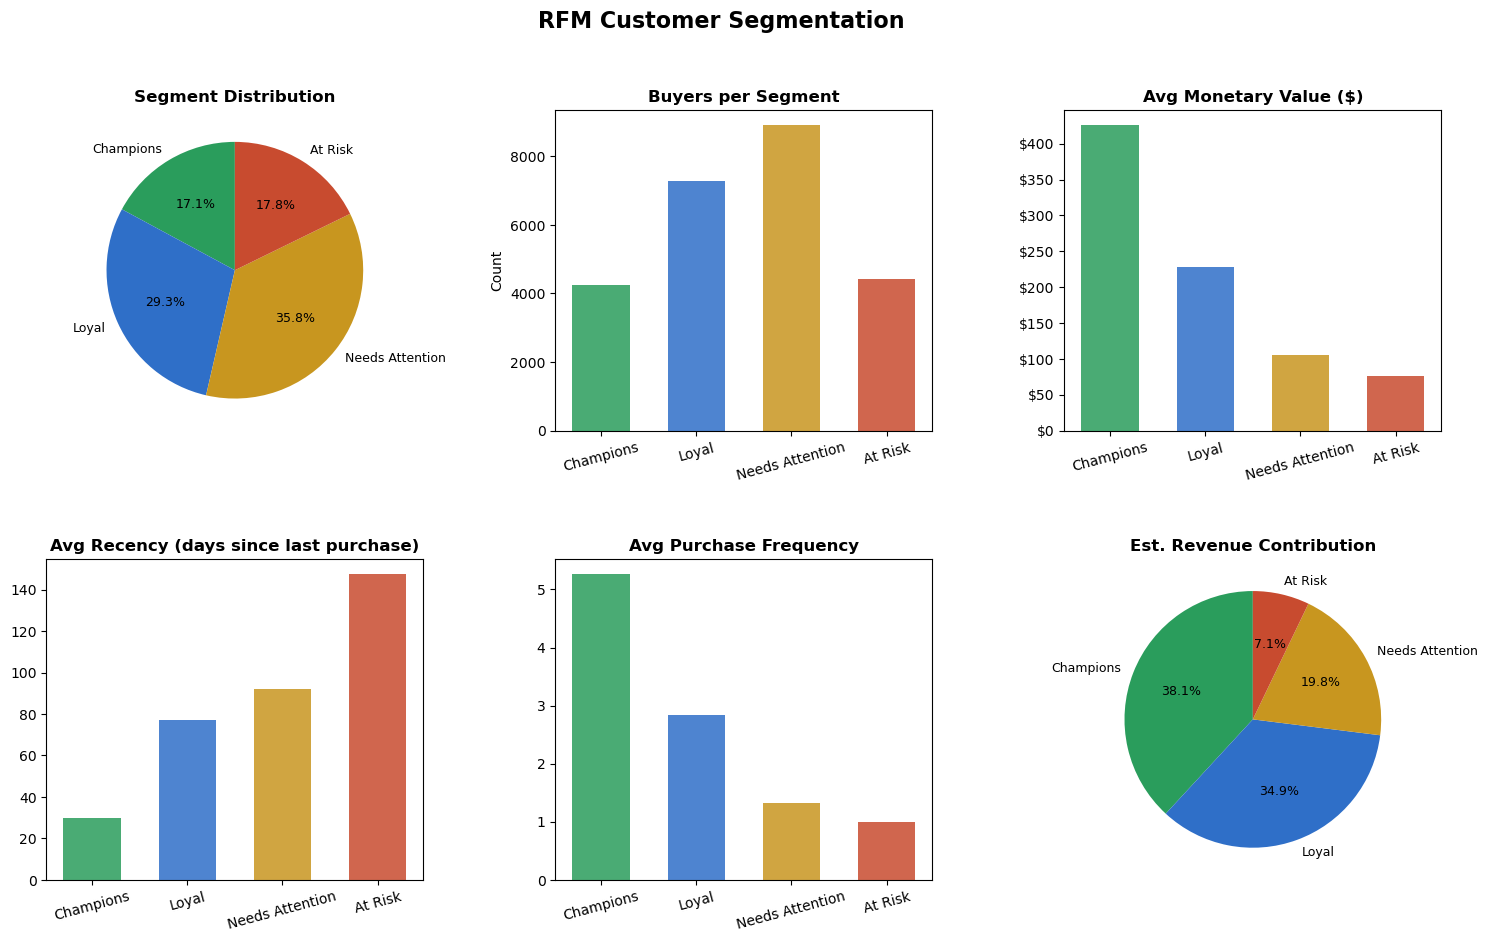

In [52]:
seg_counts  = rfm['Segment'].value_counts()
seg_stats   = rfm.groupby('Segment')[['Recency','Frequency','Monetary']].mean()
seg_colors  = {'Champions':'#2a9d5c','Loyal':'#2f6fc8','Needs Attention':'#c8961f','At Risk':'#c84b2f'}
seg_order   = ['Champions','Loyal','Needs Attention','At Risk']
bar_colors  = [seg_colors[s] for s in seg_order]

fig = plt.figure(figsize=(18, 10))
fig.suptitle('RFM Customer Segmentation', fontsize=16, fontweight='bold')
gs  = GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

# Pie
ax0 = fig.add_subplot(gs[0, 0])
ax0.pie(seg_counts[seg_order].values, labels=seg_order,
        colors=bar_colors, autopct='%1.1f%%', startangle=90,
        textprops={'fontsize': 9})
ax0.set_title('Segment Distribution', fontweight='bold')

# Buyer counts
ax1 = fig.add_subplot(gs[0, 1])
ax1.bar(seg_order, seg_counts[seg_order].values, color=bar_colors, alpha=0.85, width=0.6)
ax1.set_title('Buyers per Segment', fontweight='bold')
ax1.set_ylabel('Count')
ax1.tick_params(axis='x', rotation=15)

# Avg monetary
ax2 = fig.add_subplot(gs[0, 2])
ax2.bar(seg_order, seg_stats.loc[seg_order,'Monetary'].values, color=bar_colors, alpha=0.85, width=0.6)
ax2.set_title('Avg Monetary Value ($)', fontweight='bold')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.0f}'))
ax2.tick_params(axis='x', rotation=15)

# Avg recency
ax3 = fig.add_subplot(gs[1, 0])
ax3.bar(seg_order, seg_stats.loc[seg_order,'Recency'].values, color=bar_colors, alpha=0.85, width=0.6)
ax3.set_title('Avg Recency (days since last purchase)', fontweight='bold')
ax3.tick_params(axis='x', rotation=15)

# Avg frequency
ax4 = fig.add_subplot(gs[1, 1])
ax4.bar(seg_order, seg_stats.loc[seg_order,'Frequency'].values, color=bar_colors, alpha=0.85, width=0.6)
ax4.set_title('Avg Purchase Frequency', fontweight='bold')
ax4.tick_params(axis='x', rotation=15)

# Revenue contribution estimate
ax5 = fig.add_subplot(gs[1, 2])
rev_est = {s: seg_counts[s] * seg_stats.loc[s,'Monetary'] for s in seg_order}
ax5.pie(list(rev_est.values()), labels=seg_order,
        colors=bar_colors, autopct='%1.1f%%', startangle=90,
        textprops={'fontsize': 9})
ax5.set_title('Est. Revenue Contribution', fontweight='bold')

plt.show()

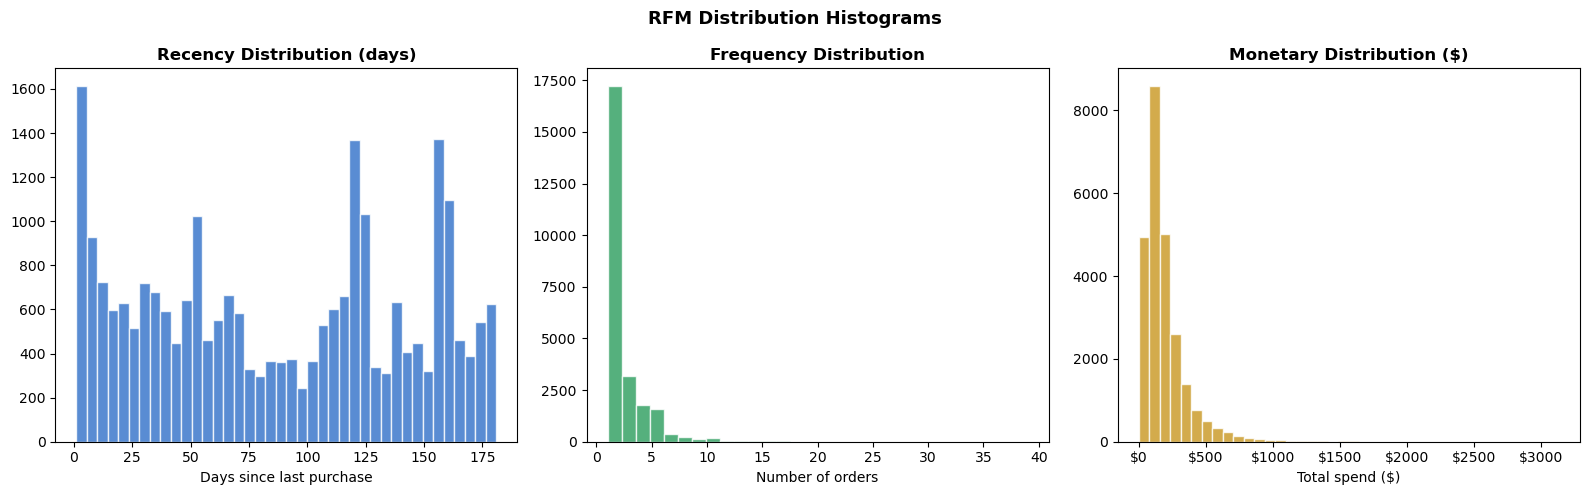


--- RFM PERCENTILE STATS ---
       Recency  Frequency  Monetary
count  24861.0    24861.0   24861.0
mean      86.8        2.4     191.3
std       55.8        2.1     171.1
min        1.0        1.0       0.0
25%       36.0        1.0      89.0
50%       87.0        2.0     142.4
75%      136.0        3.0     237.0
90%      159.0        5.0     378.6
max      181.0       39.0    3131.7


In [53]:
# RFM distribution histograms
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('RFM Distribution Histograms', fontsize=13, fontweight='bold')

axes[0].hist(rfm['Recency'],   bins=40, color=blue,   alpha=0.8, edgecolor='white')
axes[0].set_title('Recency Distribution (days)', fontweight='bold')
axes[0].set_xlabel('Days since last purchase')

axes[1].hist(rfm['Frequency'], bins=30, color=green,  alpha=0.8, edgecolor='white')
axes[1].set_title('Frequency Distribution', fontweight='bold')
axes[1].set_xlabel('Number of orders')

axes[2].hist(rfm['Monetary'],  bins=40, color=gold,   alpha=0.8, edgecolor='white')
axes[2].set_title('Monetary Distribution ($)', fontweight='bold')
axes[2].set_xlabel('Total spend ($)')
axes[2].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.0f}'))

plt.tight_layout()
plt.show()

print('\n--- RFM PERCENTILE STATS ---')
print(rfm[['Recency','Frequency','Monetary']].describe(percentiles=[.25,.5,.75,.9]).round(1))